In [2]:
import pandas as pd



In [4]:
# Load dataset
df = pd.read_csv("/city_day.csv")

# Preview
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [9]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Fill missing values
df = df.fillna(method='ffill')

# Drop missing AQI
df = df.dropna(subset=['AQI'])

# New columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df


/tmp/ipykernel_6838/1789856946.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month
28,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,2015,1
29,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,2015,1
30,Ahmedabad,2015-01-31,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,2015,1
31,Ahmedabad,2015-02-01,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe,2015,2
32,Ahmedabad,2015-02-02,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe,2015,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good,2020,6
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory,2020,6
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory,2020,6
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory,2020,6


In [11]:
# Average AQI
df['AQI'].mean()

# Top polluted cities
df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(20)

,AQI
City,
Ahmedabad,423.472993
Delhi,258.632653
Patna,229.198601
Gurugram,227.184038
Lucknow,209.797909
Talcher,157.393514
Brajrajnagar,145.627932
Jorapokhar,143.390077
Guwahati,139.539841


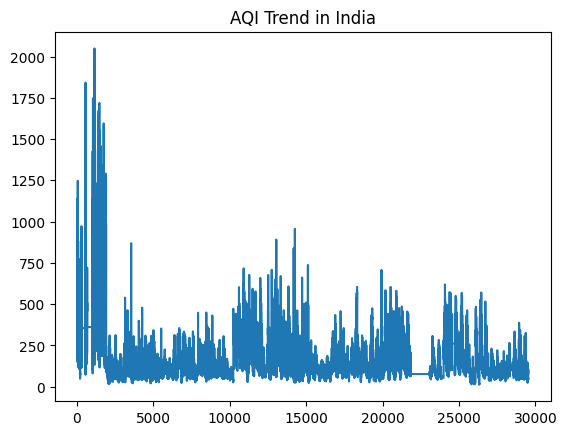

In [12]:
import matplotlib.pyplot as plt

df['AQI'].plot()
plt.title("AQI Trend in India")
plt.show()

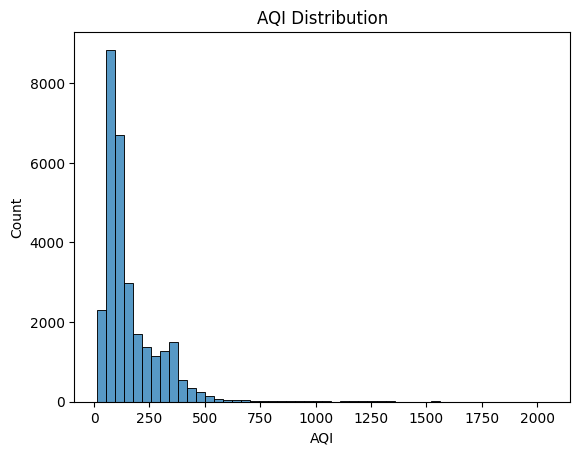

In [13]:
import seaborn as sns

sns.histplot(df['AQI'], bins=50)
plt.title("AQI Distribution")
plt.show()

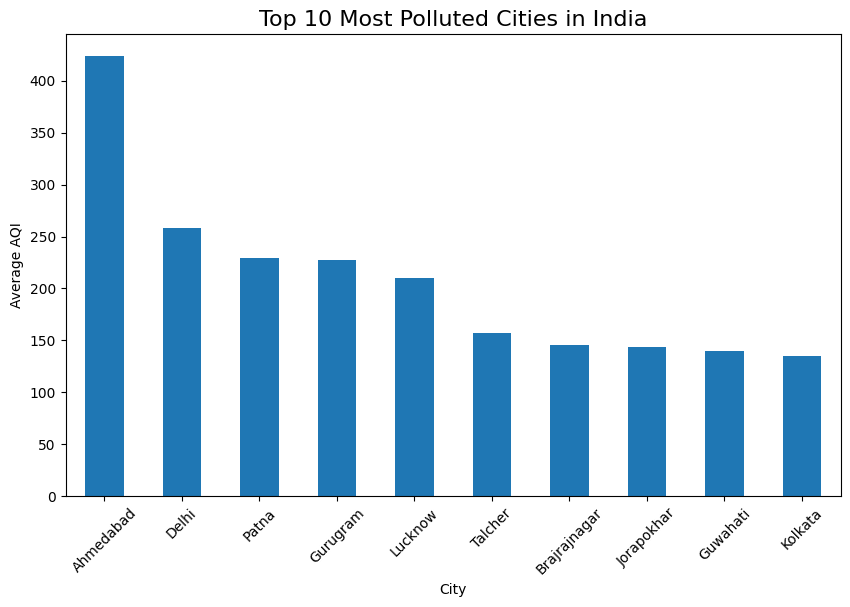

In [15]:
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_cities.plot(kind='bar')

plt.title("Top 10 Most Polluted Cities in India", fontsize=16)
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

plt.show()

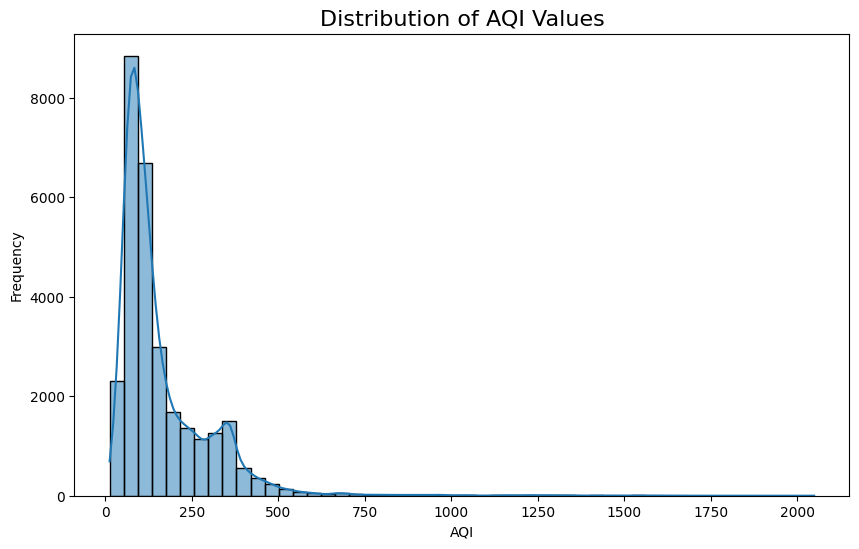

In [16]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['AQI'], bins=50, kde=True)

plt.title("Distribution of AQI Values", fontsize=16)
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

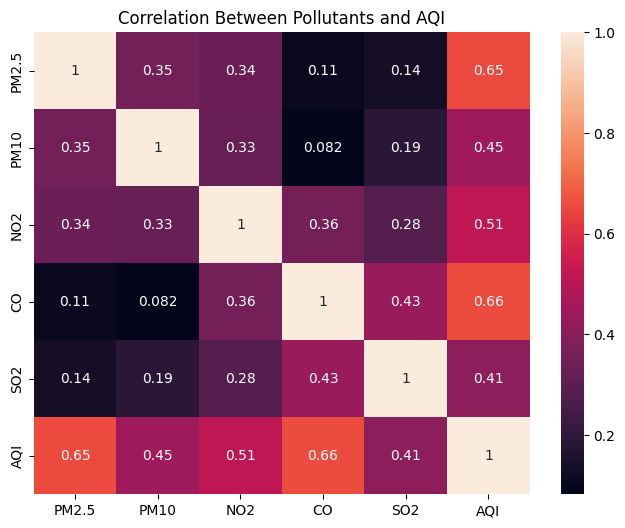

In [17]:
corr = df[['PM2.5','PM10','NO2','CO','SO2','AQI']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

plt.title("Correlation Between Pollutants and AQI")

plt.show()

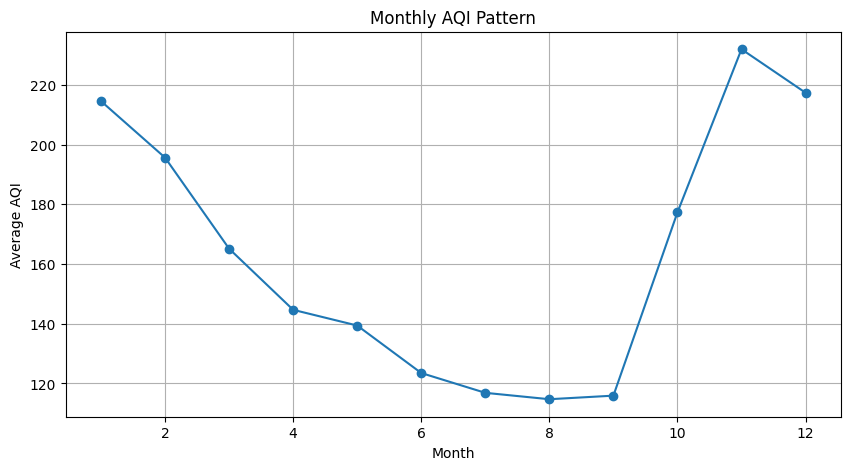

In [18]:
monthly = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')

plt.title("Monthly AQI Pattern")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(True)

plt.show()

In [19]:
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

print(top_cities)

City
Ahmedabad       423.472993
Delhi           258.632653
Patna           229.198601
Gurugram        227.184038
Lucknow         209.797909
Talcher         157.393514
Brajrajnagar    145.627932
Jorapokhar      143.390077
Guwahati        139.539841
Kolkata         135.331695
Name: AQI, dtype: float64


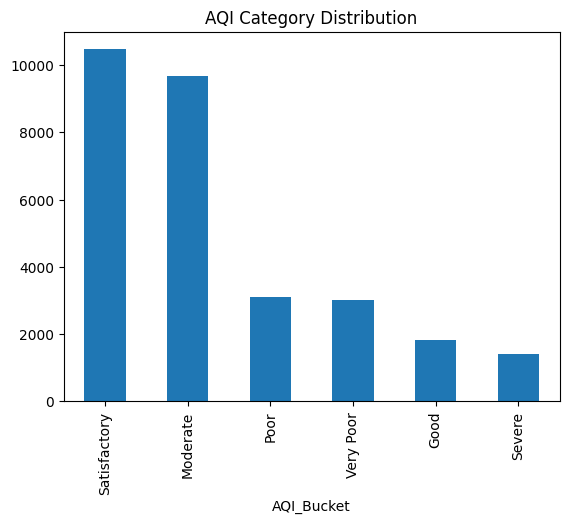

In [20]:
df['AQI_Bucket'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution")
plt.show()

In [22]:
import sqlite3

conn = sqlite3.connect("aqi.db")
df.to_sql("aqi_data", conn, if_exists='replace', index=False)

29503

In [23]:
query = """
SELECT City, AVG(AQI) as avg_aqi
FROM aqi_data
GROUP BY City
ORDER BY avg_aqi DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,City,avg_aqi
0,Ahmedabad,423.472993
1,Delhi,258.632653
2,Patna,229.198601
3,Gurugram,227.184038
4,Lucknow,209.797909
5,Talcher,157.393514
6,Brajrajnagar,145.627932
7,Jorapokhar,143.390077
8,Guwahati,139.539841
9,Kolkata,135.331695


In [24]:
query = """
SELECT Month, AVG(AQI) as avg_aqi
FROM aqi_data
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql(query, conn)

,Month,avg_aqi
0,1,214.531816
1,2,195.613350
2,3,165.123318
3,4,144.653590
4,5,139.388515
5,6,123.488083
6,7,116.855647
7,8,114.716322
8,9,115.913023
9,10,177.275298


In [25]:
query = """
SELECT AQI_Bucket, COUNT(*) as count
FROM aqi_data
GROUP BY AQI_Bucket;
"""

pd.read_sql(query, conn)

,AQI_Bucket,count
0,Good,1817
1,Moderate,9680
2,Poor,3108
3,Satisfactory,10468
4,Severe,1412
5,Very Poor,3018


Insights:
- AQI is higher in winter months
- PM2.5 and CO strongly affect AQI
- Some cities consistently show high pollution